# RF com Bandas Espectrais Pré/Pós — Saída Binária Queimada/Não-Queimada
## Detecção de áreas queimadas — Landsat 8/9

| | |
|---|---|
| **Treino** | cena `220_075` — Landsat 8 pré (21/08) / Landsat 9 pós (29/08) |
| **Teste cego** | cena `221_074` — Landsat 9 pré (20/08) / Landsat 8 pós (28/08) |
| **Features (9)** | B4/B5/B7 pré, B4/B5/B7 pós, ΔB4/ΔB5/ΔB7 |
| **Balanceamento** | `class_weight='balanced'` (sem oversampling/undersampling) |
| **Saída** | PNG binário — branco = queimada, preto = não queimada |

In [1]:
!pip install numpy matplotlib rasterio scikit-learn Pillow

In [2]:
from __future__ import annotations

import logging
import warnings
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio.warp import Resampling, reproject
from PIL import Image

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, cohen_kappa_score,
    f1_score, precision_score, recall_score,
    roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore", category=RuntimeWarning)
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger("rf_bw")

RNG_SEED       = 42
np.random.seed(RNG_SEED)

LANDSAT_SCALE  = 0.0000275
LANDSAT_OFFSET = -0.2

FEATURE_NAMES = [
    "B4_pre", "B5_pre", "B7_pre",
    "B4_post", "B5_post", "B7_post",
    "dB4", "dB5", "dB7",
]
N_FEATURES = len(FEATURE_NAMES)

OUTPUT_DIR = Path("saida_rf_bw")
OUTPUT_DIR.mkdir(exist_ok=True)

log.info("Configuração pronta — %d features", N_FEATURES)

12:27:51 [INFO] Configuração pronta — 9 features


In [3]:
@dataclass(frozen=True)
class LandsatScene:
    tag: str
    b4_pre:   Path
    b5_pre:   Path
    b7_pre:   Path
    b4_post:  Path
    b5_post:  Path
    b7_post:  Path
    mask_nbr: Path


SCENE_TRAIN = LandsatScene(
    tag      = "220_075",
    b4_pre   = Path("220_075/img_pre/LC08_L2SP_220075_20240821_20240830_02_T1_SR_B4.tif"),
    b5_pre   = Path("220_075/img_pre/LC08_L2SP_220075_20240821_20240830_02_T1_SR_B5.tif"),
    b7_pre   = Path("220_075/img_pre/LC08_L2SP_220075_20240821_20240830_02_T1_SR_B7.tif"),
    b4_post  = Path("220_075/img_pos/LC09_L2SP_220075_20240829_20240830_02_T1_SR_B4.tif"),
    b5_post  = Path("220_075/img_pos/LC09_L2SP_220075_20240829_20240830_02_T1_SR_B5.tif"),
    b7_post  = Path("220_075/img_pos/LC09_L2SP_220075_20240829_20240830_02_T1_SR_B7.tif"),
    mask_nbr = Path("220_075/mascara_0_1/mascara_1_0_areaqueimada_lim_0-65_nbr.tif"),
)

SCENE_TEST = LandsatScene(
    tag      = "221_074",
    b4_pre   = Path("221_074/img_pre/LC09_L2SP_221074_20240820_20240821_02_T1_SR_B4.tif"),
    b5_pre   = Path("221_074/img_pre/LC09_L2SP_221074_20240820_20240821_02_T1_SR_B5.tif"),
    b7_pre   = Path("221_074/img_pre/LC09_L2SP_221074_20240820_20240821_02_T1_SR_B7.tif"),
    b4_post  = Path("221_074/img_pos/LC08_L2SP_221074_20240828_20240831_02_T1_SR_B4.tif"),
    b5_post  = Path("221_074/img_pos/LC08_L2SP_221074_20240828_20240831_02_T1_SR_B5.tif"),
    b7_post  = Path("221_074/img_pos/LC08_L2SP_221074_20240828_20240831_02_T1_SR_B7.tif"),
    mask_nbr = Path("221_074/mascara_0_1/mascara_1_0_areaqueimada_lim_0-65_nbr.tif"),
)

log.info("Treino: %s | Teste cego: %s", SCENE_TRAIN.tag, SCENE_TEST.tag)

12:27:51 [INFO] Treino: 220_075 | Teste cego: 221_074


In [4]:
def _warp(src_path: Path, ref_path: Path,
          resampling=Resampling.bilinear) -> np.ndarray:
    with rasterio.open(ref_path) as ref:
        shape, transform, crs = ref.shape, ref.transform, ref.crs
    out = np.full(shape, np.nan, dtype=np.float32)
    with rasterio.open(src_path) as src:
        reproject(
            source=rasterio.band(src, 1), destination=out,
            src_transform=src.transform, src_crs=src.crs,
            dst_transform=transform, dst_crs=crs,
            resampling=resampling, src_nodata=src.nodata, dst_nodata=np.nan,
        )
    return out


def load_sr(src_path: Path, ref_path: Path) -> np.ndarray:
    raw = _warp(src_path, ref_path)
    return np.where(np.isfinite(raw),
                    raw * LANDSAT_SCALE + LANDSAT_OFFSET,
                    np.nan).astype(np.float32)


def load_mask(path: Path) -> np.ndarray:
    """0 = não queimada | 1 = queimada | -1 = inválido/nodata"""
    with rasterio.open(path) as src:
        raw = src.read(1).astype(np.float32)
        nd  = src.nodata
    out = np.full(raw.shape, -1, dtype=np.int8)
    out[raw == 0] = 0
    out[raw == 1] = 1
    if nd is not None:
        out[raw == nd] = -1
    return out


def build_features(scene: LandsatScene) -> tuple[np.ndarray, np.ndarray]:
    """Retorna (cube H×W×9, mask H×W)."""
    ref = scene.mask_nbr
    log.info("[%s] carregando bandas pré...", scene.tag)
    b4_pre  = load_sr(scene.b4_pre,  ref)
    b5_pre  = load_sr(scene.b5_pre,  ref)
    b7_pre  = load_sr(scene.b7_pre,  ref)

    log.info("[%s] carregando bandas pós...", scene.tag)
    b4_post = load_sr(scene.b4_post, ref)
    b5_post = load_sr(scene.b5_post, ref)
    b7_post = load_sr(scene.b7_post, ref)

    cube = np.stack([
        b4_pre,  b5_pre,  b7_pre,
        b4_post, b5_post, b7_post,
        (b4_pre - b4_post).astype(np.float32),
        (b5_pre - b5_post).astype(np.float32),
        (b7_pre - b7_post).astype(np.float32),
    ], axis=-1)

    log.info("[%s] carregando máscara NBR...", scene.tag)
    mask = load_mask(ref)
    log.info("[%s] cubo=%s  máscara=%s", scene.tag, cube.shape, mask.shape)
    return cube, mask


def flatten_valid(cube: np.ndarray, mask: np.ndarray):
    """Vetoriza, remove NaN e máscara=-1. Retorna (X, y, valid_flat_bool)."""
    Xf = cube.reshape(-1, N_FEATURES)
    yf = mask.ravel()
    valid = (yf >= 0) & np.all(np.isfinite(Xf), axis=1)
    return Xf[valid], yf[valid].astype(np.int8), valid


def batch_predict(model, X: np.ndarray, *, chunk=500_000, label=""):
    n = X.shape[0]
    preds = np.empty(n, dtype=np.int8)
    for s in range(0, n, chunk):
        e = min(s + chunk, n)
        preds[s:e] = model.predict(X[s:e]).astype(np.int8)
        if label:
            log.info("%s: %d/%d (%.0f%%)", label, e, n, 100 * e / n)
    return preds

## 1. Treino — cena `220_075`

In [5]:
log.info("Carregando cena de treino: %s", SCENE_TRAIN.tag)
cube_tr, mask_tr = build_features(SCENE_TRAIN)
H_tr, W_tr = mask_tr.shape

n_burn   = int((mask_tr == 1).sum())
n_unburn = int((mask_tr == 0).sum())
n_inv    = int((mask_tr == -1).sum())
total    = mask_tr.size

log.info(
    "Grade %d×%d | queimada=%d (%.2f%%) não-queimada=%d (%.2f%%) inválido=%d (%.2f%%)",
    H_tr, W_tr,
    n_burn,   100 * n_burn   / total,
    n_unburn, 100 * n_unburn / total,
    n_inv,    100 * n_inv    / total,
)

12:27:51 [INFO] Carregando cena de treino: 220_075
12:27:51 [INFO] [220_075] carregando bandas pré...
12:27:57 [INFO] [220_075] carregando bandas pós...
12:28:03 [INFO] [220_075] carregando máscara NBR...
12:28:04 [INFO] [220_075] cubo=(7691, 7581, 9)  máscara=(7691, 7581)
12:28:04 [INFO] Grade 7691×7581 | queimada=3199001 (5.49%) não-queimada=37274412 (63.93%) inválido=17832058 (30.58%)


12:28:06 [INFO] Pixels válidos: 40473413
12:28:23 [INFO] Sub-amostra: 100000 px | queimada=7.90%
12:28:23 [INFO] Treinando Random Forest...
12:28:36 [INFO] RF treinado | OOB score: 0.9968


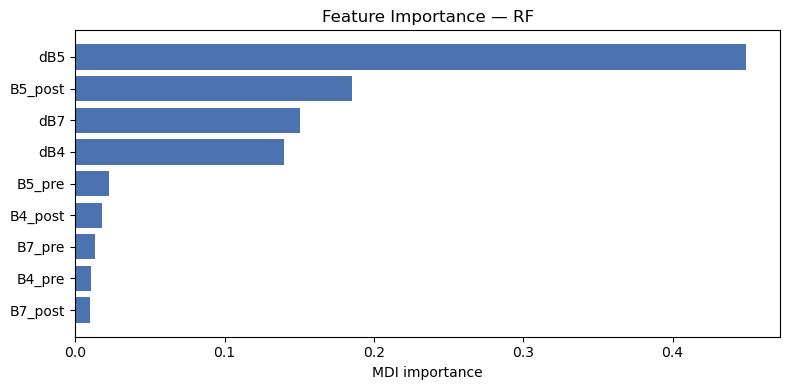

In [6]:
X_all, y_all, _ = flatten_valid(cube_tr, mask_tr)
log.info("Pixels válidos: %d", len(y_all))

# Sub-amostra estratificada para treino (100 k pixels)
SUBSAMPLE = 100_000
X_sub, _, y_sub, _ = train_test_split(
    X_all, y_all,
    train_size=SUBSAMPLE, stratify=y_all, random_state=RNG_SEED,
)
log.info(
    "Sub-amostra: %d px | queimada=%.2f%%",
    len(y_sub), 100 * y_sub.mean(),
)

log.info("Treinando Random Forest...")
rf = RandomForestClassifier(
    n_estimators=300,
    max_features="sqrt",
    class_weight="balanced",
    bootstrap=True,
    oob_score=True,
    n_jobs=-1,
    random_state=RNG_SEED,
)
rf.fit(X_sub, y_sub)
log.info("RF treinado | OOB score: %.4f", rf.oob_score_)

# Importância de features
fig, ax = plt.subplots(figsize=(8, 4))
order = np.argsort(rf.feature_importances_)
ax.barh(np.arange(N_FEATURES), rf.feature_importances_[order], color="#4c72b0")
ax.set_yticks(np.arange(N_FEATURES))
ax.set_yticklabels([FEATURE_NAMES[i] for i in order])
ax.set_xlabel("MDI importance")
ax.set_title("Feature Importance — RF")
plt.tight_layout()
plt.show()

## 2. Teste cego — cena `221_074`

Aplicamos o modelo a uma cena **nunca vista** durante o treino (sensor, data e fenologia diferentes).

In [7]:
log.info("Carregando cena de teste cego: %s", SCENE_TEST.tag)
cube_te, mask_te = build_features(SCENE_TEST)
H_te, W_te = mask_te.shape

X_te, y_te, valid_te = flatten_valid(cube_te, mask_te)
log.info(
    "Grade %d×%d | pixels válidos=%d (%.2f%%) | queimada=%.2f%%",
    H_te, W_te, len(y_te),
    100 * len(y_te) / (H_te * W_te), 100 * y_te.mean(),
)

12:28:37 [INFO] Carregando cena de teste cego: 221_074
12:28:37 [INFO] [221_074] carregando bandas pré...
12:28:42 [INFO] [221_074] carregando bandas pós...
12:28:49 [INFO] [221_074] carregando máscara NBR...
12:28:49 [INFO] [221_074] cubo=(7821, 7721, 9)  máscara=(7821, 7721)
12:28:51 [INFO] Grade 7821×7721 | pixels válidos=40137022 (66.47%) | queimada=4.89%


12:28:52 [INFO] teste (221_074): 500000/40137022 (1%)
12:28:53 [INFO] teste (221_074): 1000000/40137022 (2%)
12:28:54 [INFO] teste (221_074): 1500000/40137022 (4%)
12:28:55 [INFO] teste (221_074): 2000000/40137022 (5%)
12:28:56 [INFO] teste (221_074): 2500000/40137022 (6%)
12:28:57 [INFO] teste (221_074): 3000000/40137022 (7%)
12:28:58 [INFO] teste (221_074): 3500000/40137022 (9%)
12:28:59 [INFO] teste (221_074): 4000000/40137022 (10%)
12:29:00 [INFO] teste (221_074): 4500000/40137022 (11%)
12:29:01 [INFO] teste (221_074): 5000000/40137022 (12%)
12:29:02 [INFO] teste (221_074): 5500000/40137022 (14%)
12:29:03 [INFO] teste (221_074): 6000000/40137022 (15%)
12:29:04 [INFO] teste (221_074): 6500000/40137022 (16%)
12:29:05 [INFO] teste (221_074): 7000000/40137022 (17%)
12:29:06 [INFO] teste (221_074): 7500000/40137022 (19%)
12:29:07 [INFO] teste (221_074): 8000000/40137022 (20%)
12:29:08 [INFO] teste (221_074): 8500000/40137022 (21%)
12:29:09 [INFO] teste (221_074): 9000000/40137022 (22%)



=== Métricas — cena cega 221_074 ===
  Accuracy  : 0.9976
  Precision : 0.9854
  Recall    : 0.9649
  F1        : 0.9750
  Kappa     : 0.9738

              precision    recall  f1-score   support

não queimada       1.00      1.00      1.00  38176151
    queimada       0.99      0.96      0.98   1960871

    accuracy                           1.00  40137022
   macro avg       0.99      0.98      0.99  40137022
weighted avg       1.00      1.00      1.00  40137022



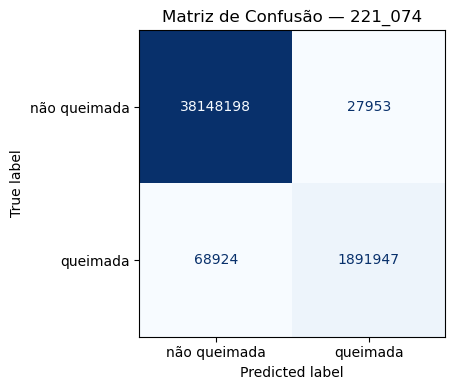

In [8]:
pred_te = batch_predict(rf, X_te, label=f"teste ({SCENE_TEST.tag})")

print("\n=== Métricas — cena cega", SCENE_TEST.tag, "===")
print(f"  Accuracy  : {accuracy_score(y_te, pred_te):.4f}")
print(f"  Precision : {precision_score(y_te, pred_te, zero_division=0):.4f}")
print(f"  Recall    : {recall_score(y_te, pred_te, zero_division=0):.4f}")
print(f"  F1        : {f1_score(y_te, pred_te, zero_division=0):.4f}")
print(f"  Kappa     : {cohen_kappa_score(y_te, pred_te):.4f}")
print()
print(classification_report(y_te, pred_te,
                             target_names=["não queimada", "queimada"],
                             zero_division=0))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_te, pred_te),
    display_labels=["não queimada", "queimada"],
).plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
ax.set_title(f"Matriz de Confusão — {SCENE_TEST.tag}")
plt.tight_layout()
plt.show()

## 3. Imagem Binária — Preto e Branco

- **Branco (255)** → queimada
- **Preto (0)** → não queimada
- **Cinza (128)** → nodata / pixel inválido

12:30:35 [INFO] PNG salvo: saida_rf_bw/classificacao_queimada_221_074.png
12:30:35 [INFO] GeoTIFF salvo: saida_rf_bw/classificacao_queimada_221_074.tif


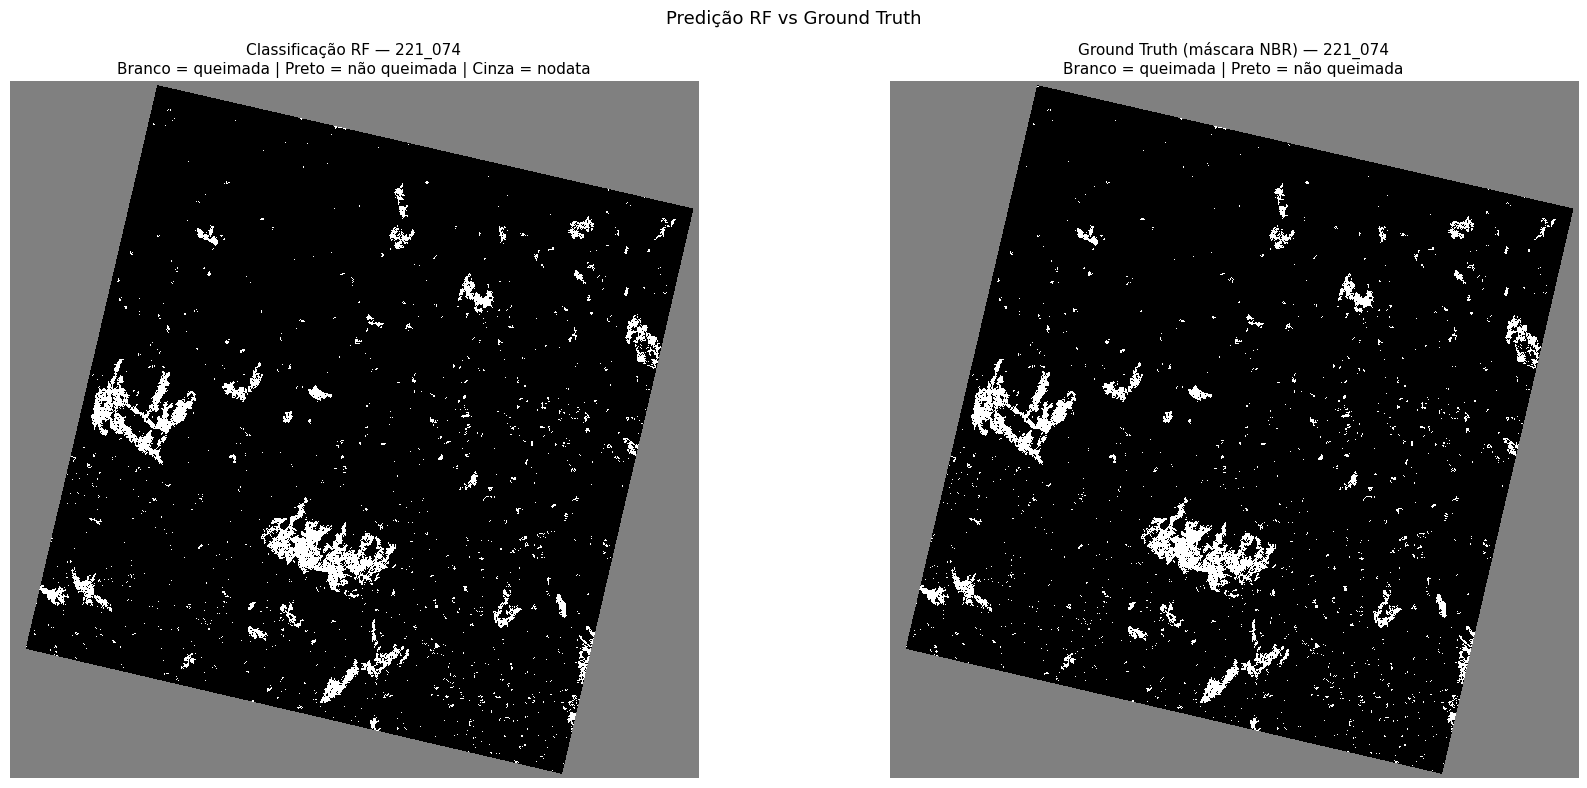


Pixels preditos (válidos): 40,137,022
  Queimada     : 1,919,900 (4.78%)
  Não queimada : 38,217,122 (95.22%)

Arquivos salvos em: /home/matheus-sales/Documents/atividade_reconhecimento/saida_rf_bw


In [9]:
# Reconstrói mapa 2D completo
pred_map = np.full(H_te * W_te, -1, dtype=np.int8)
pred_map[valid_te] = pred_te
pred_map = pred_map.reshape(H_te, W_te)

# Monta imagem em escala de cinza
bw = np.full((H_te, W_te), 128, dtype=np.uint8)  # nodata = cinza
bw[pred_map == 0] = 0    # não queimada → preto
bw[pred_map == 1] = 255  # queimada     → branco

# Salva PNG
out_png = OUTPUT_DIR / f"classificacao_queimada_{SCENE_TEST.tag}.png"
Image.fromarray(bw, mode="L").save(out_png)
log.info("PNG salvo: %s", out_png)

# Salva GeoTIFF georeferenciado (útil para abrir em SIG)
out_tif = OUTPUT_DIR / f"classificacao_queimada_{SCENE_TEST.tag}.tif"
with rasterio.open(SCENE_TEST.mask_nbr) as ref:
    profile = ref.profile.copy()
profile.update(dtype=rasterio.uint8, count=1, nodata=128)
with rasterio.open(out_tif, "w", **profile) as dst:
    dst.write(bw, 1)
log.info("GeoTIFF salvo: %s", out_tif)

# Exibe inline
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

axes[0].imshow(bw, cmap="gray", vmin=0, vmax=255, interpolation="none")
axes[0].set_title(
    f"Classificação RF — {SCENE_TEST.tag}\n"
    "Branco = queimada | Preto = não queimada | Cinza = nodata",
    fontsize=11,
)
axes[0].axis("off")

# Ground truth ao lado para comparação
gt_bw = np.full((H_te, W_te), 128, dtype=np.uint8)
gt_bw[mask_te == 0] = 0
gt_bw[mask_te == 1] = 255
axes[1].imshow(gt_bw, cmap="gray", vmin=0, vmax=255, interpolation="none")
axes[1].set_title(
    f"Ground Truth (máscara NBR) — {SCENE_TEST.tag}\n"
    "Branco = queimada | Preto = não queimada",
    fontsize=11,
)
axes[1].axis("off")

plt.suptitle("Predição RF vs Ground Truth", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"comparacao_{SCENE_TEST.tag}.png", dpi=150, bbox_inches="tight")
plt.show()

# Estatísticas da predição
total_valid = int((pred_map >= 0).sum())
n_pred_burn   = int((pred_map == 1).sum())
n_pred_unburn = int((pred_map == 0).sum())
print(f"\nPixels preditos (válidos): {total_valid:,}")
print(f"  Queimada     : {n_pred_burn:,} ({100 * n_pred_burn / total_valid:.2f}%)")
print(f"  Não queimada : {n_pred_unburn:,} ({100 * n_pred_unburn / total_valid:.2f}%)")
print(f"\nArquivos salvos em: {OUTPUT_DIR.resolve()}")